#### 파이썬으로 데이터 주무르기 by 민형기 도서의 예제

1. 서울시 자치구별 데이터
- 서울시 자치구별 cctv 설치 데이터
- 서울시 자치구별 인구 데이터

### 분석내용
1. 서울시 각 구별 cctv 수를 확인하고 인구대비 cctv 비율을 구해 구별 순위 비교
2. 인구대비 cctv 평균치를 확인 cctv가 과하게 부족한 구를 확인
    - cctv 설치가 영향을 미치는 인구 데이터를 찾아보기
    - 전체인구, 외국인, 고령자 인구 그룹이 cctv 설치에 영향을 미친 그룹이 있는지 통계검증(상관검증)을 활용해서 확인

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity="all"

In [4]:
# 한글 문제
# matplotlit의 기본 폰트에서 한글 지원되지 않기 때문에
# matplotlib의 폰트 변경 필요
import platform

from matplotlib import font_manager, rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Darwin':  # 맥OS 
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':  # 윈도우
    path = "c:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print('Unknown system...  sorry~~~')

1. 관련 파일 읽어와서 파일 상태 확인 후 전처리
- 결측치 정리
- 컬럼명으로 변환
- 행 인덱스 변경
- data type 확인 후 형변환

In [6]:
# cctv data 읽어오기
cctv_seoul = pd.read_csv('./data/01. CCTV_in_Seoul.csv')
cctv_seoul.head()

,기관명,소계,2013년도 이전,2014년,2015년,2016년
0,강남구,3238,1292,430,584,932
1,강동구,1010,379,99,155,377
2,강북구,831,369,120,138,204
3,강서구,911,388,258,184,81
4,관악구,2109,846,260,390,613


In [9]:
# df의 컬럼명 추출
cctv_seoul.columns

Index(['기관명', '소계', '2013년도 이전', '2014년', '2015년', '2016년'], dtype='object')

In [10]:
# 기관명이 자치구에 해당하므로 기관명 -> 구별 로 변경
# df.rename(columns={바꿀데이터위치:새로운값}) - 컬럼명이 변경된 df를 반환
# 최종 저장까지 하려면 inplace=True
cctv_seoul.rename(columns={cctv_seoul.columns[0]:'구별'},
                        inplace=True)

In [11]:
cctv_seoul.head(2)

,구별,소계,2013년도 이전,2014년,2015년,2016년
0,강남구,3238,1292,430,584,932
1,강동구,1010,379,99,155,377


In [14]:
# 인구데이터 : 엑셀파일
# pd.read_excel('파일명')
pop_seoul=pd.read_excel('./data/01.population_in_Seoul.xls')
pop_seoul.head()

,기간,자치구,세대,인구,인구.1,인구.2,인구.3,인구.4,인구.5,인구.6,인구.7,인구.8,세대당인구,65세이상고령자
0,기간,자치구,세대,합계,합계,합계,한국인,한국인,한국인,등록외국인,등록외국인,등록외국인,세대당인구,65세이상고령자
1,기간,자치구,세대,계,남자,여자,계,남자,여자,계,남자,여자,세대당인구,65세이상고령자
2,2017.1/4,합계,4202888,10197604,5000005,5197599,9926968,4871560,5055408,270636,128445,142191,2.36,1321458
3,2017.1/4,종로구,72654,162820,79675,83145,153589,75611,77978,9231,4064,5167,2.11,25425
4,2017.1/4,중구,59481,133240,65790,67450,124312,61656,62656,8928,4134,4794,2.09,20764


In [13]:
# ImportError: Missing optional dependency 'xlrd'. Install xlrd >= 2.0.1 for xls Excel support Use pip or conda to install xlrd.
!pip install --user xlrd

     ---------------------------------------- 0.0/96.5 kB ? eta -:--:--
     ---- ----------------------------------- 10.2/96.5 kB ? eta -:--:--
     -------------------- ----------------- 51.2/96.5 kB 650.2 kB/s eta 0:00:01
     -------------------------------- ----- 81.9/96.5 kB 762.6 kB/s eta 0:00:01
     -------------------------------------- 96.5/96.5 kB 690.3 kB/s eta 0:00:00


In [15]:
# 필요 data만 추출해서 data load
# 사용할 열 : 자치구, 전체인구수, 한국인, 외국인, 고령자
# usecols='선택열'
# header=2 2행을 header로 처리
pop_seoul=pd.read_excel('./data/01.population_in_Seoul.xls',
                       header=2,
                       usecols='B,D,G,J,N')
pop_seoul.head()

,자치구,계,계.1,계.2,65세이상고령자
0,합계,10197604.0,9926968.0,270636.0,1321458.0
1,종로구,162820.0,153589.0,9231.0,25425.0
2,중구,133240.0,124312.0,8928.0,20764.0
3,용산구,244203.0,229456.0,14747.0,36231.0
4,성동구,311244.0,303380.0,7864.0,39997.0


In [18]:
pop_seoul.rename(columns={pop_seoul.columns[0]:'구별',
                         pop_seoul.columns[1]:'인구수',
                         pop_seoul.columns[2]:'한국인',
                         pop_seoul.columns[3]:'외국인',
                         pop_seoul.columns[4]:'고령자'},inplace=True)
pop_seoul.head()

,구별,인구수,한국인,외국인,고령자
0,합계,10197604.0,9926968.0,270636.0,1321458.0
1,종로구,162820.0,153589.0,9231.0,25425.0
2,중구,133240.0,124312.0,8928.0,20764.0
3,용산구,244203.0,229456.0,14747.0,36231.0
4,성동구,311244.0,303380.0,7864.0,39997.0


In [20]:
# 각 df 개요 확인
cctv_seoul.info()
pop_seoul.info() # 불필요한 행 2개가 있음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   구별         25 non-null     object
 1   소계         25 non-null     int64 
 2   2013년도 이전  25 non-null     int64 
 3   2014년      25 non-null     int64 
 4   2015년      25 non-null     int64 
 5   2016년      25 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 1.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   구별      26 non-null     object 
 1   인구수     26 non-null     float64
 2   한국인     26 non-null     float64
 3   외국인     26 non-null     float64
 4   고령자     26 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1.2+ KB


In [22]:
# 인구데이터의 0번행은 합계 데이터-> 삭제
# df.drop()함수 사용
pop_seoul.drop([0], inplace=True)

In [24]:
pop_seoul.head()
pop_seoul.info()

,구별,인구수,한국인,외국인,고령자
1,종로구,162820.0,153589.0,9231.0,25425.0
2,중구,133240.0,124312.0,8928.0,20764.0
3,용산구,244203.0,229456.0,14747.0,36231.0
4,성동구,311244.0,303380.0,7864.0,39997.0
5,광진구,372164.0,357211.0,14953.0,42214.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 1 to 26
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   구별      25 non-null     object 
 1   인구수     25 non-null     float64
 2   한국인     25 non-null     float64
 3   외국인     25 non-null     float64
 4   고령자     25 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1.1+ KB


In [26]:
# 구별(자치구) 중복 되지 않았는지 확인
# df.unique() : 중복데이터 제외하고 반환
len(pop_seoul.구별.unique())

26

In [29]:
# isnull() : 값이  null(NaN, None)이면 True를 반환
# pop_seoul.구별.isnull()
pop_seoul[pop_seoul.구별.isnull()]

,구별,인구수,한국인,외국인,고령자
26,NaN,NaN,NaN,NaN,NaN


In [30]:
# 26행 제거
pop_seoul.drop(26,inplace=True)

In [31]:
pop_seoul.tail(2)

,구별,인구수,한국인,외국인,고령자
24,송파구,667483.0,660584.0,6899.0,72506.0
25,강동구,453233.0,449019.0,4214.0,54622.0


In [32]:
pop_seoul.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 1 to 25
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   구별      25 non-null     object 
 1   인구수     25 non-null     float64
 2   한국인     25 non-null     float64
 3   외국인     25 non-null     float64
 4   고령자     25 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1.1+ KB


In [33]:
pop_seoul.구별.unique()
set(cctv_seoul.구별)
# 25개의 자치구 각각 존재

array(['종로구', '중구', '용산구', '성동구', '광진구', '동대문구', '중랑구', '성북구', '강북구',
       '도봉구', '노원구', '은평구', '서대문구', '마포구', '양천구', '강서구', '구로구', '금천구',
       '영등포구', '동작구', '관악구', '서초구', '강남구', '송파구', '강동구'], dtype=object)

{'강남구',
 '강동구',
 '강북구',
 '강서구',
 '관악구',
 '광진구',
 '구로구',
 '금천구',
 '노원구',
 '도봉구',
 '동대문구',
 '동작구',
 '마포구',
 '서대문구',
 '서초구',
 '성동구',
 '성북구',
 '송파구',
 '양천구',
 '영등포구',
 '용산구',
 '은평구',
 '종로구',
 '중구',
 '중랑구'}

- 절대 data 이용해서 몇가지 내용을 시각화 확인
- 분석에 필요한 가공필드 생성

In [35]:
# cctv 설치 대수가 적은 5개 구를 확인
cctv_seoul.sort_values(by='소계').head(5)
# 도봉구가 설치대수가 가장 작다

,구별,소계,2013년도 이전,2014년,2015년,2016년
9,도봉구,825,238,159,42,386
2,강북구,831,369,120,138,204
5,광진구,878,573,78,53,174
3,강서구,911,388,258,184,81
24,중랑구,916,509,121,177,109


In [36]:
# cctv 설치 대수가 많은 5개 구를 확인
cctv_seoul.sort_values(by='소계', ascending=False).head(5)
# 강남구가 설치대수가 가장 많다

,구별,소계,2013년도 이전,2014년,2015년,2016년
0,강남구,3238,1292,430,584,932
18,양천구,2482,1843,142,30,467
14,서초구,2297,1406,157,336,398
4,관악구,2109,846,260,390,613
21,은평구,2108,1138,224,278,468


### 최근 증가율 가공 필드 생성
- 설치대수는 절대량으로는 도봉가 가장 적다
    - 도봉구는 설치를 늘리지 않고 있는지, 또는 늘려도 적은수를 늘리고 있는지 확인
- 최근증가율 = ((최근 3개년 설치대수)/2013년도 이전 설치대수 ) * 100

In [37]:
cctv_seoul['최근증가율'] = (cctv_seoul['2014년']+
                      cctv_seoul['2015년']+
                      cctv_seoul['2016년']) / cctv_seoul['2013년도 이전'] * 100

In [38]:
cctv_seoul.head()

,구별,소계,2013년도 이전,2014년,2015년,2016년,최근증가율
0,강남구,3238,1292,430,584,932,150.619195
1,강동구,1010,379,99,155,377,166.490765
2,강북구,831,369,120,138,204,125.203252
3,강서구,911,388,258,184,81,134.793814
4,관악구,2109,846,260,390,613,149.290780


In [39]:
# 최근 3개년동안 cctv 설치 증가율이 높은 3개 구
cctv_seoul.sort_values(by='최근증가율', ascending=False).head(3)

,구별,소계,2013년도 이전,2014년,2015년,2016년,최근증가율
22,종로구,1619,464,314,211,630,248.922414
9,도봉구,825,238,159,42,386,246.638655
12,마포구,980,314,118,169,379,212.101911


### 인구 데이터의 가공필드 생성/기본 분석

In [40]:
pop_seoul.head()

,구별,인구수,한국인,외국인,고령자
1,종로구,162820.0,153589.0,9231.0,25425.0
2,중구,133240.0,124312.0,8928.0,20764.0
3,용산구,244203.0,229456.0,14747.0,36231.0
4,성동구,311244.0,303380.0,7864.0,39997.0
5,광진구,372164.0,357211.0,14953.0,42214.0


In [41]:
# 어느 구의 인구가 가장 많은가?
pop_seoul.sort_values(by='인구수', ascending=False).head()
# 송파, 강서, 강남

,구별,인구수,한국인,외국인,고령자
24,송파구,667483.0,660584.0,6899.0,72506.0
16,강서구,603772.0,597248.0,6524.0,72548.0
23,강남구,570500.0,565550.0,4950.0,63167.0
11,노원구,569384.0,565565.0,3819.0,71941.0
21,관악구,525515.0,507203.0,18312.0,68082.0


In [42]:
# 어느 구의 고령자 인구수가 가장 많은가?
pop_seoul.sort_values(by='고령자', ascending=False).head()
# 강서, 송파, 은평
# 외국인 수가 많은 자치구는?
pop_seoul.sort_values(by='외국인', ascending=False).head()
# 영등포구, 구로, 금천

,구별,인구수,한국인,외국인,고령자
16,강서구,603772.0,597248.0,6524.0,72548.0
24,송파구,667483.0,660584.0,6899.0,72506.0
12,은평구,494388.0,489943.0,4445.0,72334.0
11,노원구,569384.0,565565.0,3819.0,71941.0
21,관악구,525515.0,507203.0,18312.0,68082.0


,구별,인구수,한국인,외국인,고령자
19,영등포구,402985.0,368072.0,34913.0,52413.0
17,구로구,447874.0,416487.0,31387.0,56833.0
18,금천구,255082.0,236353.0,18729.0,32970.0
21,관악구,525515.0,507203.0,18312.0,68082.0
6,동대문구,369496.0,354079.0,15417.0,54173.0


In [43]:
# 지자체별로 전체 인구수 대비 고령자/외국인의 비율 계산
pop_seoul['외국인비율']=pop_seoul['외국인']/pop_seoul['인구수']*100
pop_seoul['고령자비율']=pop_seoul['고령자']/pop_seoul['인구수']*100

In [44]:
pop_seoul.head()

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
1,종로구,162820.0,153589.0,9231.0,25425.0,5.669451,15.615404
2,중구,133240.0,124312.0,8928.0,20764.0,6.700690,15.583909
3,용산구,244203.0,229456.0,14747.0,36231.0,6.038828,14.836427
4,성동구,311244.0,303380.0,7864.0,39997.0,2.526635,12.850689
5,광진구,372164.0,357211.0,14953.0,42214.0,4.017852,11.342849


In [45]:
# 인구수 대비 외국인 비율이 높은 자치구
pop_seoul.sort_values(by='외국인비율',ascending=False).head()
# 전통적으로 외국인이 많이 거주하는 영등포/구로/금천이 높게 나타났고
# 중구/용산구는 오피스가 많은 지역 인구는 많지 않지만 파견된 외국인들이 많이 거주하는
# 지역으로 알려져 있음

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
19,영등포구,402985.0,368072.0,34913.0,52413.0,8.663598,13.006191
18,금천구,255082.0,236353.0,18729.0,32970.0,7.342345,12.925255
17,구로구,447874.0,416487.0,31387.0,56833.0,7.007998,12.689506
2,중구,133240.0,124312.0,8928.0,20764.0,6.700690,15.583909
3,용산구,244203.0,229456.0,14747.0,36231.0,6.038828,14.836427


In [46]:
# 인구수 대비 고령자 비율이 높은 자치구
pop_seoul.sort_values(by='고령자비율',ascending=False).head()
# 강북구는 절대적인 고령자수는 적은지역(2017년도 당시는 개발이 덜된 구도심 지역)
# 토박이분들이 많은 지역
# 종로구, 중구, 용산 대표적인 오피스 지역이면서 구도심-토박이분들이 많은 지역

# 단, 2017년도 기준이기때문에 2023년도에는 많은 변화가 있음

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
9,강북구,330192.0,326686.0,3506.0,54813.0,1.061806,16.600342
1,종로구,162820.0,153589.0,9231.0,25425.0,5.669451,15.615404
2,중구,133240.0,124312.0,8928.0,20764.0,6.700690,15.583909
3,용산구,244203.0,229456.0,14747.0,36231.0,6.038828,14.836427
13,서대문구,327163.0,314982.0,12181.0,48161.0,3.723221,14.720797


### 인구수 대비 cctv 적정성을 확인
- 두 df를 병합한 후 새로운 data 생성 해서 분석

In [47]:
# 구별 컬럼명을 기준으로 병합
data_result = pd.merge(cctv_seoul, pop_seoul,on='구별')
data_result.head()

,구별,소계,2013년도 이전,2014년,2015년,2016년,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
0,강남구,3238,1292,430,584,932,150.619195,570500.0,565550.0,4950.0,63167.0,0.867660,11.072217
1,강동구,1010,379,99,155,377,166.490765,453233.0,449019.0,4214.0,54622.0,0.929765,12.051638
2,강북구,831,369,120,138,204,125.203252,330192.0,326686.0,3506.0,54813.0,1.061806,16.600342
3,강서구,911,388,258,184,81,134.793814,603772.0,597248.0,6524.0,72548.0,1.080540,12.015794
4,관악구,2109,846,260,390,613,149.290780,525515.0,507203.0,18312.0,68082.0,3.484582,12.955291


In [51]:
# 불필요한 컬럼 삭제
# del 명령어 사용 : 원본에 무조건 반영
del data_result['2013년도 이전']
del data_result['2014년']
del data_result['2015년']
del data_result['2016년']

In [49]:
data_result.head()

,구별,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
0,강남구,3238,150.619195,570500.0,565550.0,4950.0,63167.0,0.867660,11.072217
1,강동구,1010,166.490765,453233.0,449019.0,4214.0,54622.0,0.929765,12.051638
2,강북구,831,125.203252,330192.0,326686.0,3506.0,54813.0,1.061806,16.600342
3,강서구,911,134.793814,603772.0,597248.0,6524.0,72548.0,1.080540,12.015794
4,관악구,2109,149.290780,525515.0,507203.0,18312.0,68082.0,3.484582,12.955291


In [53]:
# 행 인덱스로 구별 컬럼을 설정함
# 판다스 패키지를 이용한 시각화 진행할 때 효율적임
# df.set_index(컬럼명, inplace=True)
data_result.set_index('구별',inplace=True)

In [54]:
data_result.head(2)

,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
구별,,,,,,,,
강남구,3238,150.619195,570500.0,565550.0,4950.0,63167.0,0.867660,11.072217
강동구,1010,166.490765,453233.0,449019.0,4214.0,54622.0,0.929765,12.051638


### 인구와 관련된 data와 cctv 관련한 data들 간의 선형적인 상관성이 있는지 확인
- 상관계수 분석
    - 계수값이 절대값으로 0.3을 넘어가면 상관관계가 있다
        - 0.1 이하면 무시
        - 0.7 이상이면 아주 강한 상관관계(자기 상관 의심)
        - 0.1 < 계수 <= 0.3 약한 상관관계
        - 값이 - 면 음의 상관 : 두 변수의 값 중 하나의 변수값 증가하면 나머지 변수의 값은 감소한다
        - 값이 + 면 양의 상관 : 두 변수의 값 중 하나의 변수값 증가/감소하면 나머지 변수의 값도 증가/감소한다
- df.corr() 상관계수를 구해주는 함수

In [55]:
data_result.corr()

,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
소계,1.000000,-0.264378,0.243220,0.238638,0.027950,0.175518,-0.052302,-0.258663
최근증가율,-0.264378,1.000000,-0.093068,-0.082511,-0.150463,-0.070969,-0.044042,0.185089
인구수,0.243220,-0.093068,1.000000,0.998061,-0.153371,0.932667,-0.591939,-0.669462
한국인,0.238638,-0.082511,0.998061,1.000000,-0.214576,0.931636,-0.637911,-0.660812
외국인,0.027950,-0.150463,-0.153371,-0.214576,1.000000,-0.155381,0.838904,-0.014055
고령자,0.175518,-0.070969,0.932667,0.931636,-0.155381,1.000000,-0.606088,-0.380468
외국인비율,-0.052302,-0.044042,-0.591939,-0.637911,0.838904,-0.606088,1.000000,0.267348
고령자비율,-0.258663,0.185089,-0.669462,-0.660812,-0.014055,-0.380468,0.267348,1.000000


In [57]:
# np.corrcoef(데이터값1, 데이터값2)
np.corrcoef(data_result['소계'],data_result['인구수'])
# 약한 양의 상관

array([[1.       , 0.2432198],
       [0.2432198, 1.       ]])

In [58]:
np.corrcoef(data_result['소계'],data_result['고령자비율'])
# 약한 음의 상관

array([[ 1.        , -0.25866272],
       [-0.25866272,  1.        ]])

In [59]:
np.corrcoef(data_result['소계'],data_result['외국인비율'])
# 관계가 없음

array([[ 1.        , -0.05230165],
       [-0.05230165,  1.        ]])

- cctv 절대수와 전체 인구수가 약하지만 양의 상관 관계가 있으므로 두 데이터를 활용해서 data상 인구대비 적정 cctv 대수 추정 
    - 고령자 비율도 음의 상관이 있지만 전체 인구를 이야기 하지 않으므로 제외

## cctv vs 인구현황 기본 시각화

In [60]:
data_result.head()

,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
구별,,,,,,,,
강남구,3238,150.619195,570500.0,565550.0,4950.0,63167.0,0.867660,11.072217
강동구,1010,166.490765,453233.0,449019.0,4214.0,54622.0,0.929765,12.051638
강북구,831,125.203252,330192.0,326686.0,3506.0,54813.0,1.061806,16.600342
강서구,911,134.793814,603772.0,597248.0,6524.0,72548.0,1.080540,12.015794
관악구,2109,149.290780,525515.0,507203.0,18312.0,68082.0,3.484582,12.955291


<Figure size 1000x1000 with 0 Axes>

<Axes: ylabel='구별'>

<Figure size 1000x1000 with 0 Axes>

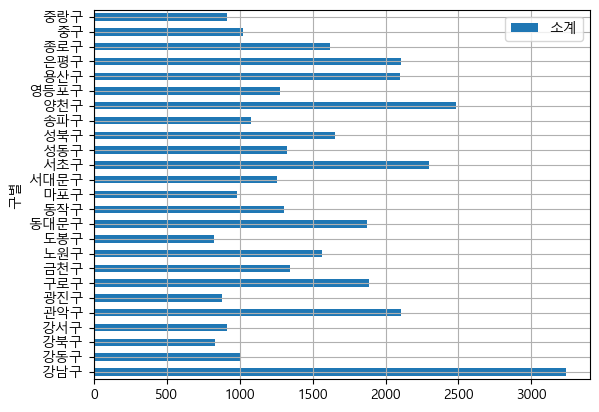

In [63]:
# 전체 자치구별 cctv 절대 대수의 차이 확인 그래프
plt.figure(figsize=(10,10))
data_result[['소계']].plot(kind='barh', grid=True)
plt.show()

<Figure size 800x800 with 0 Axes>

<Axes: ylabel='구별'>

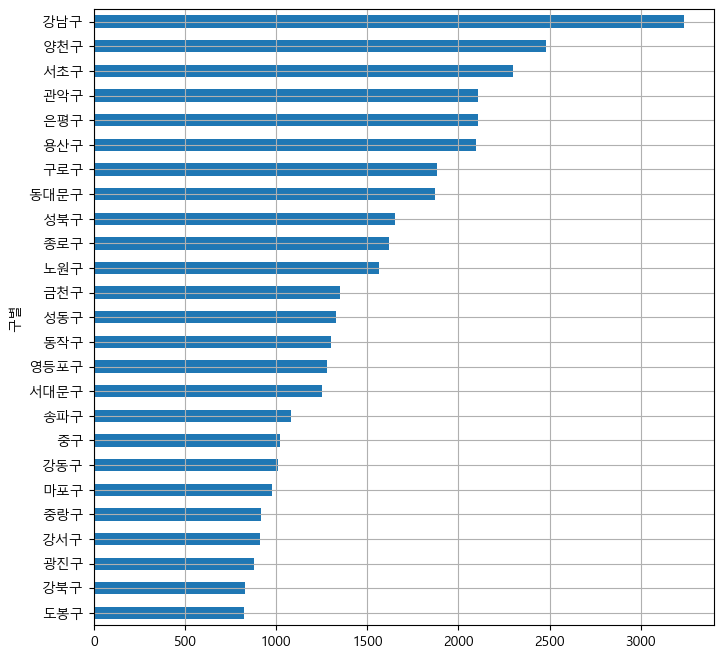

In [65]:
# data 정렬 후 시각화
plt.figure(figsize=(8,8))
sort_cctv = data_result['소계'].sort_values()
sort_cctv.plot(kind='barh',grid=True)
plt.show()

### 강남구와 도봉구의 cctv 절대 대수의 차이는 굉장히 큼
- 인구수 대비  cctv 설치 비율을 확인해서 절대대수와의 차이를 확인
- 인구수 대비 cctv 설치 비율 가공필드 생성

In [66]:
data_result['cctv비율']=data_result['소계']/data_result['인구수']*100
data_result.head()

,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율,cctv비율
구별,,,,,,,,,
강남구,3238,150.619195,570500.0,565550.0,4950.0,63167.0,0.867660,11.072217,0.567572
강동구,1010,166.490765,453233.0,449019.0,4214.0,54622.0,0.929765,12.051638,0.222843
강북구,831,125.203252,330192.0,326686.0,3506.0,54813.0,1.061806,16.600342,0.251672
강서구,911,134.793814,603772.0,597248.0,6524.0,72548.0,1.080540,12.015794,0.150885
관악구,2109,149.290780,525515.0,507203.0,18312.0,68082.0,3.484582,12.955291,0.401321


<Axes: ylabel='구별'>

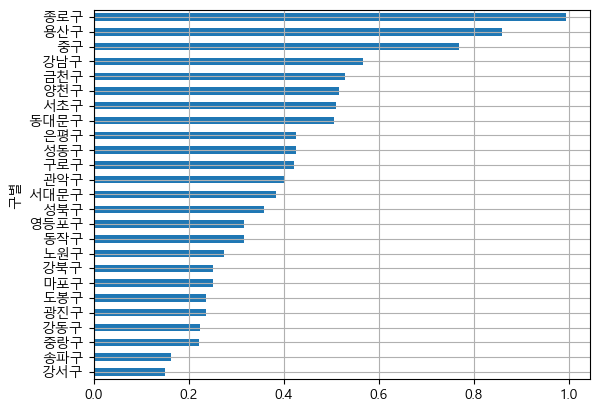

In [68]:
# 자치구별 인구대비 cctv 비율의 차이
data_result['cctv비율'].sort_values().plot(kind='barh',grid=True)

- 용산, 중구, 종로, 강남구는 대표적으로 유동인구가 많은 지역임
    - 거주인원보다 유동인원이 많은
    - 유동인구의 영향으로 인구대비 cctv 비율이 높다

### 약한 양의 상관관계를 보이는 구별 cctv 수와 구별 인구수와의  관계 표현 분산그래프

Text(0.5, 0, '인구수')

Text(0, 0.5, '구별 cctv 수')

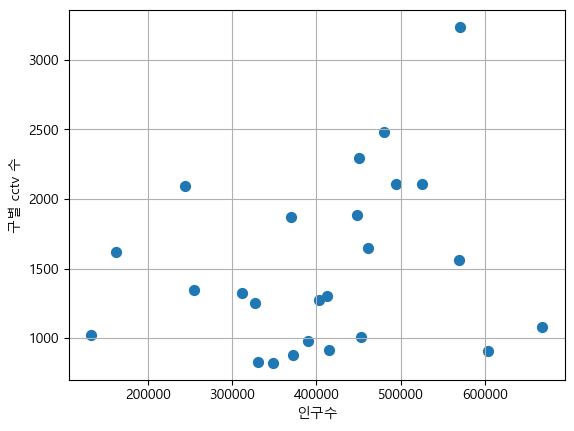

In [69]:
plt.scatter(data_result.인구수, data_result.소계, s=50)
plt.xlabel('인구수')
plt.ylabel('구별 cctv 수')
plt.grid()

In [70]:
import seaborn as sns

- sns의 lmplot()
    - 그래프의 data를 대표하는 대표직선을 포함해서 그래프에 표시

C:\Users\USER\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


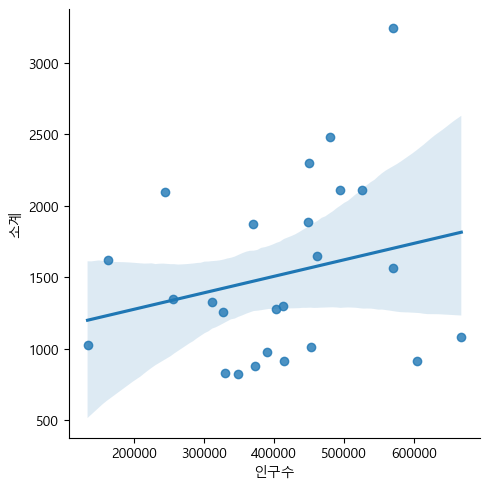

In [71]:
sns.lmplot(x='인구수', y='소계', data=data_result)

## 인구수와 cctv 소계 데이터의 관계를 표현할 대표 직선을 수동으로 그림
- 대표직선을 그리고 인구대비 적정 cctv 대수를 확인
- 대표직선을 이용해서 적정cctv 대수보다 많거나 적은 10 개 자치구에 표시

In [ ]:
data_result.to_csv('./data/data_result.csv')